In [1]:
%%latex
\newcounter{none}

<IPython.core.display.Latex object>

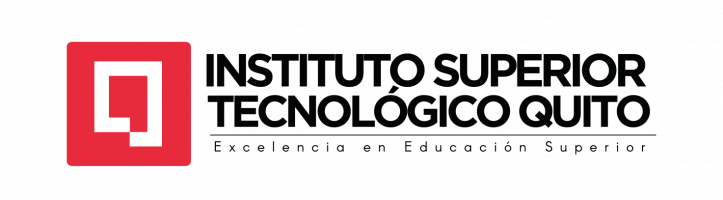

##  01PAO26-26 - Variables cuantitavas

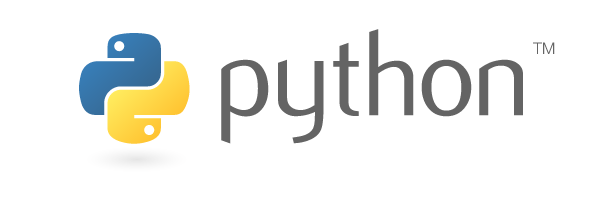

*Mathew Santiago Lara Villalva*

*Link del Git Hub: [Mathew Lara](https://github.com/MathewLara/CuadernoPythonML1.git)*

In [2]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
            -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)

[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [3]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [4]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)

RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


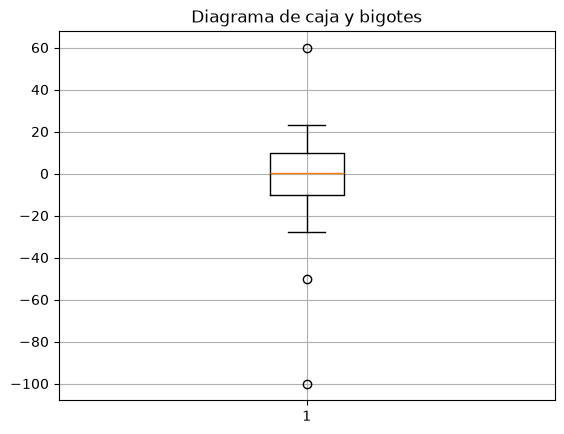

In [5]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [6]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [7]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [3]:
import numpy as np
from sklearn import datasets
import scipy.stats as stats

# Cargar el set de datos de Iris
iris = datasets.load_iris()
X = iris.data

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???
asimetria = stats.skew(X[:, 2])
print("Asimetría (Longitud del pétalo): ", np.round(asimetria, 4))

if asimetria < 0:
    print("Asimetría negativa (hacia la izquierda)\n")
elif asimetria > 0:
    print("Asimetría positiva (hacia la derecha)\n")
else:
    print("Distribución Simétrica\n")


# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
#???
curtosis = stats.kurtosis(X[:, 1], fisher=True)
print("Curtosis (Ancho del sépalo): ", np.round(curtosis, 4))

# Tu lógica de condicionales intacta:
if curtosis > 0:
    print("Distribución Leptocúrtica")
elif curtosis < 0:
    print("Distribución Platicúrtica")
else:
    print("Distribución Mesocúrtica")

1. Coeficiente de Asimetría (Petal Length): -0.2749
Tipo: Asimetría NEGATIVA (hacia la izquierda)

2. Coeficiente de Curtosis (Sepal Width): 0.2282
Tipo de distribución: MESOCÚRTICA (se ajusta a una Distribución Normal)


In [10]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)

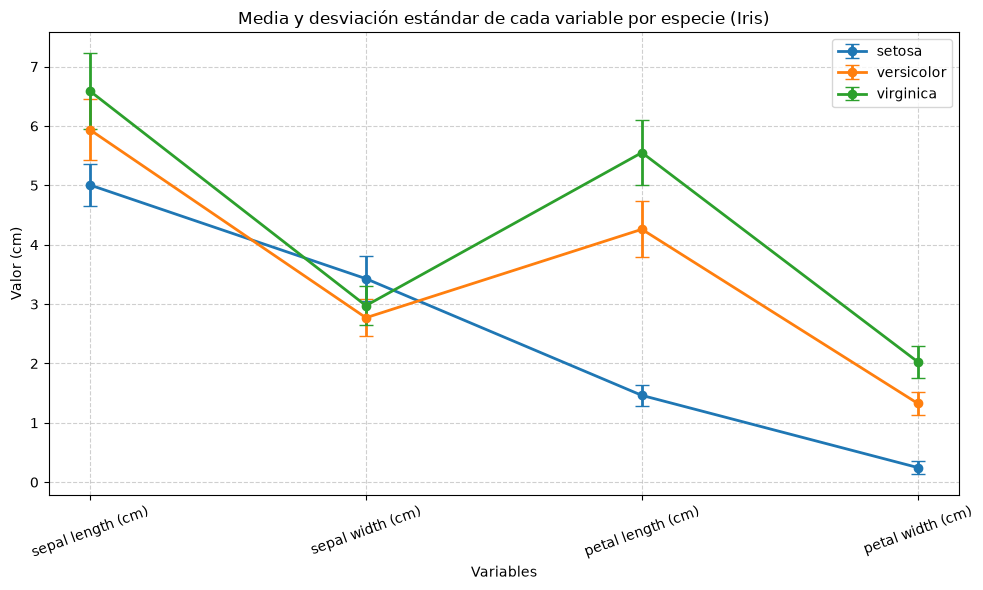

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

# 1. Cargar el dataset de Iris desde scikit-learn
iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
# Añadimos la columna con el nombre en texto de cada especie
df["species"] = [iris_raw.target_names[i] for i in iris_raw.target]

# 2. Calcular la media y la desviación estándar agrupadas por especie
medias = df.groupby("species").mean()
desviaciones = df.groupby("species").std()

# 3. Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# 4. Dibujar una línea con barras de error (errorbar) para cada especie
especies = ["setosa", "versicolor", "virginica"]

for especie in especies:
    plt.errorbar(
        x=medias.columns,  # Las 4 variables anatómicas
        y=medias.loc[especie],  # El valor medio
        yerr=desviaciones.loc[especie],  # La desviación estándar para las barras
        label=especie,  # Nombre para la leyenda
        marker="o",  # Puntos circulares en cada dato
        linewidth=2,  # Grosor de la línea
        capsize=5,  # Tamaño de los topes horizontales en la barra de error
    )

# 5. Personalización estética idéntica a la imagen
plt.title(
    "Media y desviación estándar de cada variable por especie (Iris)",
    fontsize=12,
)
plt.xlabel("Variables")
plt.ylabel("Valor (cm)")

# Rotación de 20° para que las etiquetas del eje X queden inclinadas
plt.xticks(rotation=20)

# Cuadrícula gris punteada de fondo
plt.grid(True, linestyle="--", alpha=0.6)

# Mostrar leyenda en la esquina superior derecha
plt.legend()

# Ajustar márgenes para que no se corte ningún texto y mostrar
plt.tight_layout()
plt.show()

El resultado debería ser algo como esto: